In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import rankdata, norm
from itertools import product as iproduct

In [2]:
from utils import *
from tests import *

In [3]:
SETTINGS_MULTI = ['Noise', 'Heteroskedastic', 'Nonlinear Additive', 'Interaction', 'Interaction & Additive', 'Radial']

In [4]:
COLORS  = {"MDD": "red", "dCov": "purple", "pMIT [r=0.8]": "orange", "pMIT [formula]": "brown", "AC": "green", "NCMD [k=5]": "dodgerblue", "NCMD [k=10]" : "navy"}
MARKERS = {"MDD": "P",       "dCov": "s",  "pMIT [r=0.8]": "X",  "pMIT [formula]": "H",     "AC": "p",       "NCMD [k=5]": "o", "NCMD [k=10]" : "*"}

SETTING_LABELS_MULTI = {
    "Noise":                 "Noise [Type-I]",
    "Heteroskedastic":  "Heteroskedastic [Type-I]",
    "Nonlinear Additive":    "Nonlinear Additive [Power]",
    "Interaction":           "Interaction [Power]",
    "Interaction & Additive": "Interaction & Additive [Power]",
    "Radial":                "Radial [Power]"
}

In [5]:
lambda_grid = np.linspace(0.1, 0.9, 5)

xgb_params_ = {
    "n_estimators":     4,
    "max_depth":        6,
    "learning_rate":    0.1,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "reg_lambda":       0.0,
    "reg_alpha":        0.0,
    "min_child_weight": 25,
    "verbosity":        0,
    "random_state":     None,
}

methods = {
    "dCov":        lambda X, Y: {"reject": dcov_test(X, Y, n_permutations = 199)["reject"]},
    "MDD":         lambda X, Y: {"reject": mdd_test(X, Y, n_bootstrap = 199)["reject"]},
    "pMIT [r=0.8]":        lambda X, Y: {"reject": pmit_test(X, Y, split_ratio=0.8, xgb_params=xgb_params_)["reject"]},
    "pMIT [formula]":        lambda X, Y: {"reject": pmit_test(X, Y, split_ratio="formula", xgb_params=xgb_params_)["reject"]},
    "AC":  lambda X, Y: {"reject": azadkia_chatterjee_test(X, Y)["reject"]},
    "NCMD [k=10]":  lambda X, Y: {"reject": nncmi(X, Y, k = 10)["reject"]},
    "NCMD [k=5]": lambda X, Y: {"reject": nncmi(X, Y, k = 5)["reject"]}
}

In [6]:
n = 250
n_sim = 200
seed = 42

In [7]:
results_uniform, times_uniform = run_experiment(lambda_grid, methods, SETTINGS_MULTI, n=n, n_sim=n_sim, X_setting = "uniform", seed=seed, d_X = 10, dim_X = "multivariate")

Running 6 settings in parallel (n_jobs=-1) …

  [Noise] lambda=0.10  dCov=0.030±0.012  MDD=0.035±0.013  pMIT [r=0.8]=0.100±0.021  pMIT [formula]=0.090±0.020  AC=0.035±0.013  NCMD [k=10]=0.035±0.013  NCMD [k=5]=0.025±0.011
  [Radial] lambda=0.10  dCov=0.155±0.026  MDD=0.205±0.029  pMIT [r=0.8]=0.115±0.023  pMIT [formula]=0.085±0.020  AC=0.825±0.027  NCMD [k=10]=1.000±0.000  NCMD [k=5]=0.995±0.005
  [Heteroskedastic] lambda=0.10  dCov=0.080±0.019  MDD=0.050±0.015  pMIT [r=0.8]=0.105±0.022  pMIT [formula]=0.080±0.019  AC=0.550±0.035  NCMD [k=10]=0.045±0.015  NCMD [k=5]=0.050±0.015
  [Nonlinear Additive] lambda=0.10  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=0.260±0.031  pMIT [formula]=0.065±0.017  AC=0.995±0.005  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Interaction & Additive] lambda=0.10  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=0.160±0.026  pMIT [formula]=0.075±0.019  AC=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Interaction] lambda=0.10  dCov

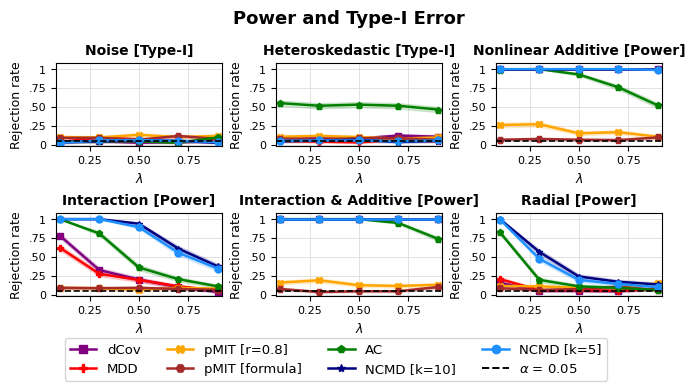

Plot saved → results/power_curves_uniform_multivariate.pdf


In [8]:
plot_power_curves(results_uniform, SETTING_LABELS_MULTI, COLORS, MARKERS, lambda_grid, col_size = 2.2, row_size=1.5, save_path="results/power_curves_uniform_multivariate.pdf")

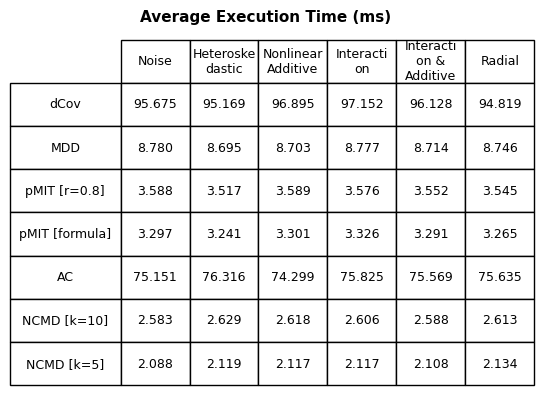

Timing table saved → results/method_times_uniform_multivariate.pdf


In [9]:
plot_times_table(times_uniform, col_width=0.59, row_height=0.57, max_row_width=15, max_col_width=9, save_path="results/method_times_uniform_multivariate.pdf")

In [10]:
results_normal, times_normal = run_experiment(lambda_grid, methods, SETTINGS_MULTI, n=n, n_sim=n_sim, X_setting = "normal", seed=seed, d_X = 10, dim_X = "multivariate")

Running 6 settings in parallel (n_jobs=-1) …

  [Nonlinear Additive] lambda=0.10  dCov=0.110±0.022  MDD=0.150±0.025  pMIT [r=0.8]=0.165±0.026  pMIT [formula]=0.065±0.017  AC=0.080±0.019  NCMD [k=10]=0.030±0.012  NCMD [k=5]=0.055±0.016
  [Radial] lambda=0.10  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=0.135±0.024  pMIT [formula]=0.045±0.015  AC=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Interaction] lambda=0.10  dCov=0.945±0.016  MDD=0.350±0.034  pMIT [r=0.8]=0.065±0.017  pMIT [formula]=0.085±0.020  AC=0.990±0.007  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Interaction & Additive] lambda=0.10  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=0.170±0.027  pMIT [formula]=0.055±0.016  AC=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Heteroskedastic] lambda=0.10  dCov=0.695±0.033  MDD=0.030±0.012  pMIT [r=0.8]=0.120±0.023  pMIT [formula]=0.070±0.018  AC=0.855±0.025  NCMD [k=10]=0.045±0.015  NCMD [k=5]=0.045±0.015
  [Noise] lambda=0.10  dCov

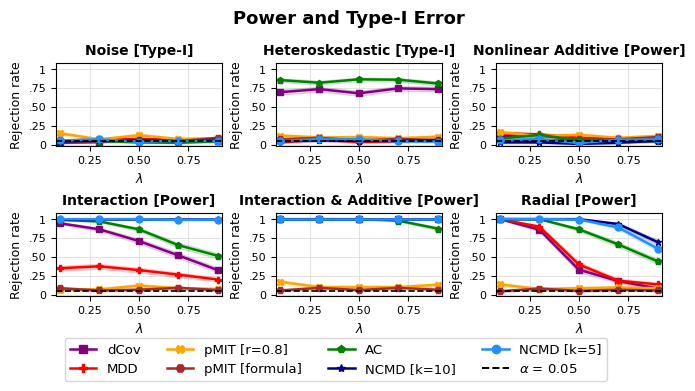

Plot saved → results/power_curves_normal_multivariate.pdf


In [11]:
plot_power_curves(results_normal, SETTING_LABELS_MULTI, COLORS, MARKERS, lambda_grid, col_size = 2.2, row_size=1.5, save_path="results/power_curves_normal_multivariate.pdf")

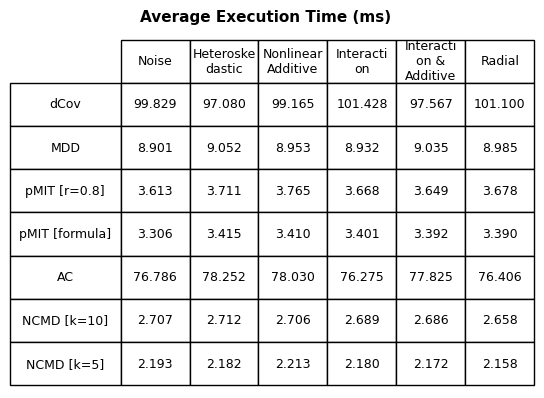

Timing table saved → results/method_times_normal_multivariate.pdf


In [12]:
plot_times_table(times_normal, col_width=0.59, row_height=0.57, max_row_width=15, max_col_width=9, save_path="results/method_times_normal_multivariate.pdf")

In [13]:
results_beta, times_beta = run_experiment(lambda_grid, methods, SETTINGS_MULTI, n=n, n_sim=n_sim, X_setting = "beta", seed=seed, d_X = 10, dim_X = "multivariate")

Running 6 settings in parallel (n_jobs=-1) …

  [Interaction & Additive] lambda=0.10  dCov=1.000±0.000  MDD=1.000±0.000  pMIT [r=0.8]=0.200±0.028  pMIT [formula]=0.045±0.015  AC=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Interaction] lambda=0.10  dCov=0.900±0.021  MDD=0.935±0.017  pMIT [r=0.8]=0.085±0.020  pMIT [formula]=0.070±0.018  AC=1.000±0.000  NCMD [k=10]=1.000±0.000  NCMD [k=5]=1.000±0.000
  [Nonlinear Additive] lambda=0.10  dCov=0.985±0.009  MDD=1.000±0.000  pMIT [r=0.8]=0.190±0.028  pMIT [formula]=0.040±0.014  AC=0.210±0.029  NCMD [k=10]=0.225±0.030  NCMD [k=5]=0.180±0.027
  [Heteroskedastic] lambda=0.10  dCov=0.055±0.016  MDD=0.065±0.017  pMIT [r=0.8]=0.110±0.022  pMIT [formula]=0.090±0.020  AC=0.115±0.023  NCMD [k=10]=0.040±0.014  NCMD [k=5]=0.030±0.012
  [Radial] lambda=0.10  dCov=0.040±0.014  MDD=0.075±0.019  pMIT [r=0.8]=0.105±0.022  pMIT [formula]=0.060±0.017  AC=0.140±0.025  NCMD [k=10]=0.935±0.017  NCMD [k=5]=0.810±0.028
  [Noise] lambda=0.10  dCov

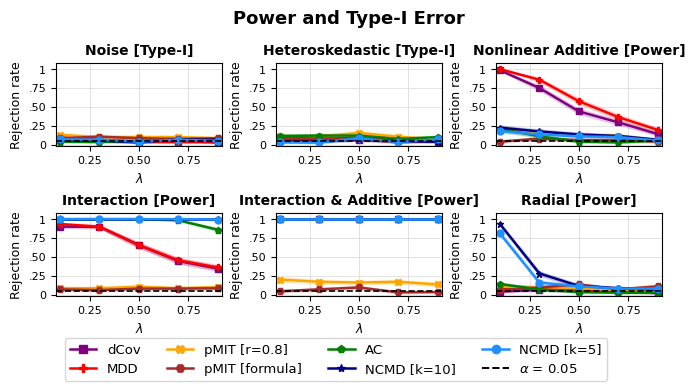

Plot saved → results/power_curves_beta_multivariate.pdf


In [14]:
plot_power_curves(results_beta, SETTING_LABELS_MULTI, COLORS, MARKERS, lambda_grid, col_size = 2.2, row_size=1.5, save_path="results/power_curves_beta_multivariate.pdf")

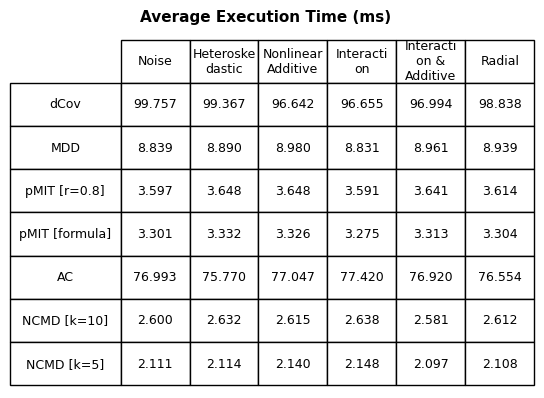

Timing table saved → results/method_times_beta_multivariate.pdf


In [15]:
plot_times_table(times_beta, col_width=0.59, row_height=0.57, max_row_width=15, max_col_width=9, save_path="results/method_times_beta_multivariate.pdf")